# 04 — Modelling

Inputs: `data/X_train.csv`, `data/X_val.csv`, `data/y_train.csv`, `data/y_val.csv`  

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'font.size': 9,
})

RANDOM_STATE = 42

## 1. Load data

In [2]:
X_train = pd.read_csv('../data/X_train.csv')
X_val   = pd.read_csv('../data/X_val.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val   = pd.read_csv('../data/y_val.csv').squeeze()

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'Train default rate: {y_train.mean():.4f}')
print(f'Val default rate:   {y_val.mean():.4f}')

X_train: (40000, 48)
X_val:   (10000, 48)
Train default rate: 0.0809
Val default rate:   0.0810


**Objective 8: Build a baseline model**

## 2. Logistic Regression

Logistic regression is the standard baseline for PD modelling, as it is interpretable, transparent and thus well understood by regulators.

It's important to note that the credit-scoring literature consistently finds that more flexible models (like gradient-boosted trees) achieve higher discrimination than logistic regression. However, the gains from complexity are usually modest in absolute terms, and they have issues, particularly due to their lack of transparency, making them hard to audit. I would be keen to explore more complex methods in the future.

In [3]:
model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## 3. Generate predictions

In [4]:
y_pred_proba = model.predict_proba(X_val)[:, 1]

print(f'PD score range: {y_pred_proba.min():.4f} — {y_pred_proba.max():.4f}')
print(f'Mean predicted PD: {y_pred_proba.mean():.4f}')
print(f'Actual default rate: {y_val.mean():.4f}')

PD score range: 0.0027 — 1.0000
Mean predicted PD: 0.0827
Actual default rate: 0.0810


## 4. Evaluation

Interpreting Coefficients:

                       feature  coefficient  odds_ratio
             ANNUITY_TO_INCOME        1.457       4.295
   EMPLOYMENT_STATUS_Pensioner       -0.515       0.598
    EMPLOYMENT_STATUS_Salaried       -0.489       0.613
    EMPLOYMENT_STATUS_Contract       -0.467       0.627
           BUREAU_DPD_90_COUNT        0.427       1.533
  NAME_CONTRACT_TYPE_Cash loan       -0.413       0.662
  NAME_CONTRACT_TYPE_Auto loan       -0.412       0.662
           HOME_OWNERSHIP_Rent       -0.387       0.679
NAME_CONTRACT_TYPE_Credit card       -0.370       0.691
         HOME_OWNERSHIP_Family       -0.369       0.691
           BUREAU_DPD_30_COUNT        0.363       1.438
       HOME_OWNERSHIP_Mortgage       -0.353       0.703


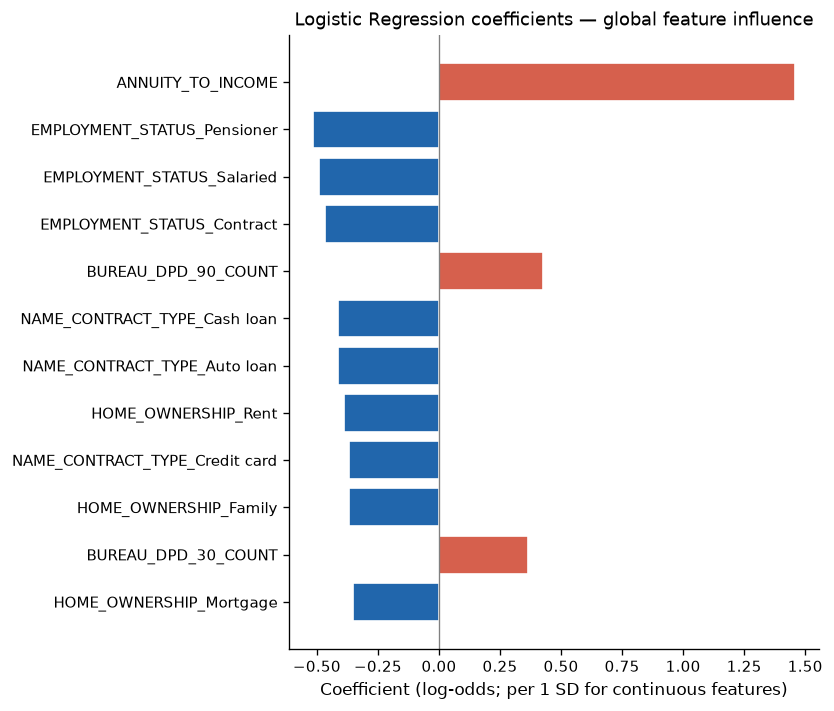

In [ ]:
coef = pd.DataFrame({'feature': X_train.columns, 'coefficient': model.coef_[0]})
coef['odds_ratio'] = np.exp(coef['coefficient'])
coef = coef.reindex(coef['coefficient'].abs().sort_values(ascending=False).index)
print(coef.head(12).round(3).to_string(index=False))

top = coef.head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top['feature'], top['coefficient'],
        color=['#d6604d' if c > 0 else '#2166ac' for c in top['coefficient']], edgecolor='white')
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Coefficient (log-odds; per 1 SD for continuous features)')
ax.set_title('Logistic Regression coefficients — global feature influence')
plt.tight_layout()
plt.show()

ANNUITY_TO_INCOME dominates by a wide margin (+1.46), confirming affordability is the primary driver of predicted risk. The only other strong risk-increasing signals are prior delinquencies, and the model ranks them by severity, as 90-day past-due (+0.43) weighs more than 30-day (+0.36). The remaining influential features are categorical (employment status, contract type, home ownership). The coefficients represent the change in log-odds of default per unit of the feature (per one standard deviation, for the standardised continuous variables).

As mentioned before, imbalances in `TARGET` make naive accuracy measure uninformative. We begin by evaluating DISCRIMINATION:

**Discrimination:** 

This is the model's ability to rank-order applicants by risk, independent of any single cut-off. We report 3 standard measures, ROC-AUC (AUC is probability that a randomly chosen defaulter is scored riskier than a randomly chosen non-defaulter; 0.5 is random ranking and 1.0 perfect ranking), Gini (Rescaled AUC, carries same information), and Kolmogorov-Smirnov (KS) Statistic (maximum separation between cumulative score distributions of defaulters and non-defaulters). 

In [5]:
auc = roc_auc_score(y_val, y_pred_proba)
gini = 2 * auc - 1

fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
ks = (tpr - fpr).max()
ks_threshold = thresholds[(tpr - fpr).argmax()]

print('Baseline Logistic Regression')
print(f'ROC-AUC:       {auc:.4f}')
print(f'Gini:          {gini:.4f}')
print(f'KS Statistic:  {ks:.4f}')
print(f'KS Threshold:  {ks_threshold:.4f}')

Baseline Logistic Regression
ROC-AUC:       0.8897
Gini:          0.7793
KS Statistic:  0.6354
KS Threshold:  0.0635


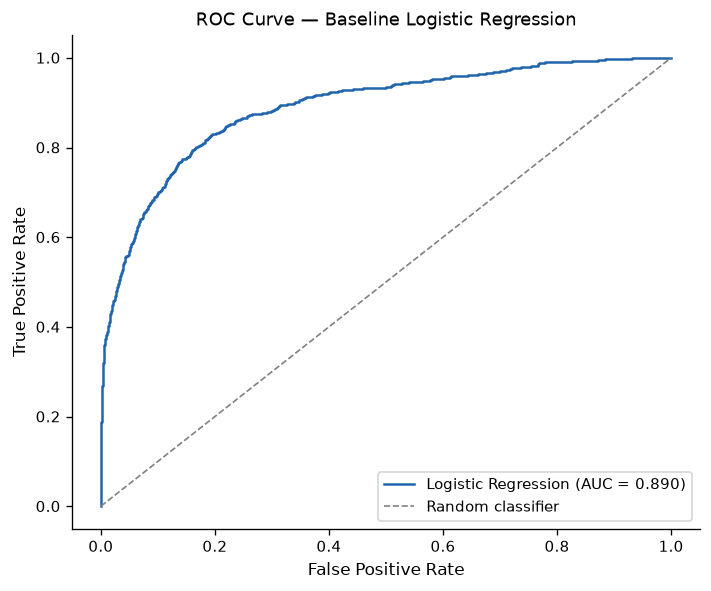

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color='#2166ac', lw=1.5, label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Baseline Logistic Regression')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Every point on the ROC curve corresponds to one decision threshold, and the two axes are the classical error rates. The x-axis is the Type I error rate (False Pos), y-axis is power (1-B, where B is Type II error rate). The ROC curve visualizes every possible combination of Type I and Type II error rates for a specific model. Higher AUC indicates that the model is better at minimizing both types of errors. AUC of 0.89, model ranks risk well.

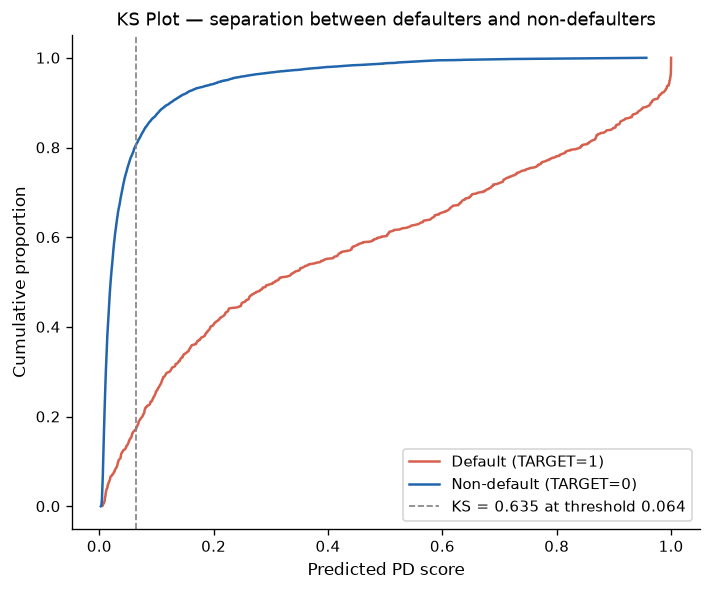

In [7]:
scores_default     = np.sort(y_pred_proba[y_val == 1])
scores_non_default = np.sort(y_pred_proba[y_val == 0])

cdf_default     = np.arange(1, len(scores_default) + 1) / len(scores_default)
cdf_non_default = np.arange(1, len(scores_non_default) + 1) / len(scores_non_default)

fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(scores_default,     cdf_default,     color='#d6604d', lw=1.5, label='Default (TARGET=1)')
ax.plot(scores_non_default, cdf_non_default, color='#2166ac', lw=1.5, label='Non-default (TARGET=0)')

ax.axvline(ks_threshold, color='gray', linestyle='--', lw=1,
           label=f'KS = {ks:.3f} at threshold {ks_threshold:.3f}')

ax.set_xlabel('Predicted PD score')
ax.set_ylabel('Cumulative proportion')
ax.set_title('KS Plot — separation between defaulters and non-defaulters')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

KS represents the tradeoff between catching defaults vs. wrongly scoring good customers. List individuals from riskiest to safest, then vary a rejection threshold, identifiying the separation between default and non-default groups (good customers). KS represents the widest that gap is. When PD is 0.065, roughly 81% of non-defaulters have been accounted for, but only 17% of defaulters. In lending terms, a cut-off at 0.065 would correctly identify around 83% of true defaulters while wrongly flagging only 19% of good customers. 

**Calibration:**

Where discrimination measures ranking, calibration measures whether the predicted probabilities are correct in level. In other words, when the model says an applicant has an 8% PD, do roughly 8% of such applicants actually default? This matters here because the PD score is not only used to rank applicants, it feeds the approve / review / decline decisions, so the probability values themselves must be trustworthy on top of being well-ordered. We report three measures: the Brier score (mean squared error between the predicted PD and the 0/1 outcome; lower is better, 0 is perfect), a reliability table / calibration curve (applicants are grouped into deciles of predicted PD and the mean predicted PD in each group is compared to the observed default rate), and the Expected Calibration Error (ECE) (the average absolute gap between predicted and observed across those bins, weighted by bin size).

In [8]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_val, y_pred_proba)
print(f'Brier score: {brier:.4f}\n')

cal = pd.DataFrame({'predicted_pd': y_pred_proba, 'actual': y_val.values})
cal['decile'] = pd.qcut(cal['predicted_pd'], 10, duplicates='drop')

reliability = cal.groupby('decile', observed=True).agg(
    mean_predicted=('predicted_pd', 'mean'),
    observed_rate=('actual', 'mean'),
    n=('actual', 'size'),
)
reliability['gap'] = reliability['mean_predicted'] - reliability['observed_rate']
print(reliability.round(4).to_string())

ece = (reliability['n'] / reliability['n'].sum() * reliability['gap'].abs()).sum()
print(f'\nExpected Calibration Error (ECE): {ece:.4f}')

Brier score: 0.0481

                                  mean_predicted  observed_rate     n     gap
decile                                                                       
(0.0017000000000000001, 0.00695]          0.0057          0.003  1000  0.0027
(0.00695, 0.00928]                        0.0081          0.005  1000  0.0031
(0.00928, 0.0122]                         0.0106          0.020  1000 -0.0094
(0.0122, 0.0162]                          0.0140          0.014  1000  0.0000
(0.0162, 0.0223]                          0.0189          0.013  1000  0.0059
(0.0223, 0.0316]                          0.0265          0.019  1000  0.0075
(0.0316, 0.0482]                          0.0391          0.035  1000  0.0041
(0.0482, 0.0844]                          0.0638          0.072  1000 -0.0082
(0.0844, 0.203]                           0.1290          0.151  1000 -0.0220
(0.203, 1.0]                              0.5110          0.478  1000  0.0330

Expected Calibration Error (ECE): 0.0096


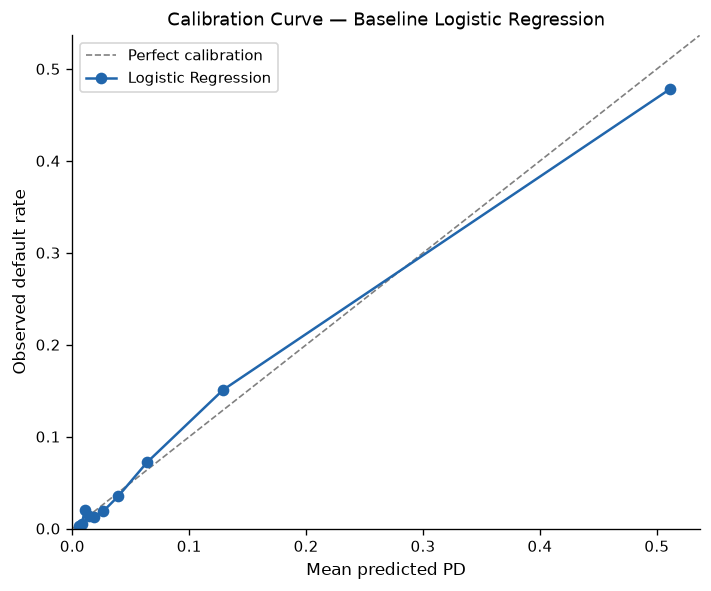

In [9]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_val, y_pred_proba, n_bins=10, strategy='quantile'
)

lim = max(prob_pred.max(), prob_true.max()) * 1.05

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, lim], [0, lim], color='gray', linestyle='--', lw=1, label='Perfect calibration')
ax.plot(prob_pred, prob_true, marker='o', color='#2166ac', lw=1.5, label='Logistic Regression')

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel('Mean predicted PD')
ax.set_ylabel('Observed default rate')
ax.set_title('Calibration Curve — Baseline Logistic Regression')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The model is well-calibrated. The Expected Calibration Error of 0.0096 indicates that, on average, predicted PDs agree with observed default rates to within roughly one percentage point, and the per-decile gaps confirm there is no systematic over or under prediction across the score range. The low Brier score (0.0481) corroborates this.